# 📊 E-Commerce Customer Insights & Purchase Behavior Analysis


## Project Overview

This project focuses on analyzing **customer behavior** in an e-commerce platform using a synthetic dataset of around **250,000 records**. The dataset includes customer demographics (age, gender, city), purchase details (product category, purchase amount), and purchase frequency. The goal is to uncover insights into customer spending patterns, handle missing data, and perform statistical tests to validate hypotheses.

---

## 🎯 Objectives

1. **Data Cleaning**: Handle missing values in the dataset using advanced technique.
    - Treat ouliner (Age > 18 < 60) (Pruschase Amount < 500).
2. **Exploratory Data Analysis (EDA)**: Analyze customer demographics and purchasing behavior.
    - create Age Group (18-25, 26-35, 36-45, 46-55, 56-60).
3. **Statistical Testing**:
   - Perform a **Two-Sample T-Test** to compare average purchase amounts between genders.
   - Perform a **Chi-Square Test** to examine the relationship between product categories and age groups.
4. **Insights and Recommendations**: Provide actionable insights to optimize marketing strategies and improve customer experience.

---

## 🔬 Dataset Description

### **Columns in the Dataset**

1. **Customer_ID**: Unique identifier for each customer.
   
   
3. **Age**: Age of the customer .
   
4. **City**: City of residence (selected from a list of German cities).
 
5. **Product_Category**: Category of the product purchased (`Electronics`, `Clothing`, `Home & Kitchen`, `Books`, `Sports`).

6. **Purchase_Amount**: Amount spent by the customer in USD.

7. **Purchase_Frequency**: Number of purchases made by the customer.
 

In [419]:
## Importing libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
from scipy import stats as st
from matplotlib import pyplot as plt

In [420]:
## Inserting dataset 

df_e = pd.read_csv('ecommerce_data.csv')

In [421]:
## checking dataset 
df_e.head(5)

,Customer_ID,Age,City,Product_Category,Purchase_Amount,Gender
0,1,39,Dresden,Electronics,291.78,Male
1,2,33,Frankfurt,Home & Kitchen,433.57,Female
2,3,41,Wuppertal,Home & Kitchen,45.83,Male
3,4,50,Frankfurt,Home & Kitchen,266.42,Female
4,5,32,Cologne,Electronics,224.23,Male


In [422]:
df_e.tail(5)

,Customer_ID,Age,City,Product_Category,Purchase_Amount,Gender
250592,250593,20,Leipzig,NaN,362.84,Male
250593,250594,31,Leipzig,Clothing,240.53,Male
250594,250595,41,Munich,Home & Kitchen,378.25,Male
250595,250596,44,Munich,Home & Kitchen,498.68,Female
250596,250597,49,Nuremberg,Books,266.66,Male


In [423]:
df_e.describe()

,Customer_ID,Age,Purchase_Amount
count,250597.000000,250597.000000,241932.000000
mean,125299.000000,34.516969,256.600543
std,72341.267041,10.051326,157.077570
min,1.000000,-9.000000,10.000000
25%,62650.000000,28.000000,132.487500
50%,125299.000000,35.000000,255.680000
75%,187948.000000,41.000000,378.050000
max,250597.000000,100.000000,4997.870000


In [424]:
df_e.shape

(250597, 6)

In [425]:
## checking for duplicate 

df_e.Customer_ID.nunique()

250597

In [426]:
## checking for null values 
df_e.isnull().sum()

Customer_ID             0
Age                     0
City                    0
Product_Category    12529
Purchase_Amount      8665
Gender                  0
dtype: int64

In [427]:
## checking relation between Purchase_Amount/Product_Category and city 

missing_value_city = df_e.groupby('City')[['Purchase_Amount','Product_Category']].apply(lambda x: x.isnull().sum())
missing_value_city

,Purchase_Amount,Product_Category
City,,
Berlin,8665,1482
Bielefeld,0,396
Bochum,0,380
Bonn,0,357
Bremen,0,497
Cologne,0,1011
Dortmund,0,748
Dresden,0,377
Duisburg,0,332


In [428]:
## Replacing Purchase_Amount null value with mean 
df_e['Purchase_Amount'] = pd.to_numeric(df_e['Purchase_Amount'], errors='coerce')

city_mean = df_e.groupby('City')['Purchase_Amount'].mean()

df_e['Purchase_Amount'] = df_e.apply(
    lambda row: city_mean[row['City']] if pd.isnull(row['Purchase_Amount']) else row['Purchase_Amount'], 
    axis=1
)
city_mean

City
Berlin        254.739257
Bielefeld     256.706836
Bochum        253.333880
Bonn          257.264941
Bremen        258.055995
Cologne       256.141011
Dortmund      257.931466
Dresden       256.100265
Duisburg      255.478524
Düsseldorf    257.422814
Essen         256.800020
Frankfurt     256.853835
Hamburg       257.212988
Hanover       257.170335
Leipzig       256.810063
Munich        256.823657
Münster       254.419532
Nuremberg     259.123723
Stuttgart     256.783420
Wuppertal     255.212554
Name: Purchase_Amount, dtype: float64

In [429]:
df_e.isnull().sum()

Customer_ID             0
Age                     0
City                    0
Product_Category    12529
Purchase_Amount         0
Gender                  0
dtype: int64

In [430]:
## replacing Product_Category null value with mode of city

city_mode = df_e.groupby('City')['Product_Category'].agg(lambda x: x.mode().iloc[0])

df_e['Product_Category'] = df_e.apply(lambda row :city_mode[row['City']] if pd.isnull(row['Product_Category']) else row['Product_Category'],axis=1)

In [431]:
df_e.isnull().sum()

Customer_ID         0
Age                 0
City                0
Product_Category    0
Purchase_Amount     0
Gender              0
dtype: int64

In [432]:
#checking for outliner 
df_e.describe()

,Customer_ID,Age,Purchase_Amount
count,250597.000000,250597.000000,250597.000000
mean,125299.000000,34.516969,256.536184
std,72341.267041,10.051326,154.338374
min,1.000000,-9.000000,10.000000
25%,62650.000000,28.000000,136.750000
50%,125299.000000,35.000000,254.739257
75%,187948.000000,41.000000,373.750000
max,250597.000000,100.000000,4997.870000


In [433]:
## Treating outliner Age
outlier_age = df_e.groupby('City')['Age'].apply(lambda x: ((x < 18) | (x > 60)).sum())
outlier_age


City
Berlin        1448
Bielefeld      376
Bochum         352
Bonn           323
Bremen         466
Cologne        996
Dortmund       764
Dresden        374
Duisburg       366
Düsseldorf     609
Essen          631
Frankfurt      857
Hamburg       1075
Hanover        379
Leipzig        488
Munich        1343
Münster        244
Nuremberg      355
Stuttgart      722
Wuppertal      316
Name: Age, dtype: int64

In [434]:
## Treating outliner with respective median
group_median = df_e.groupby('City')['Age'].median()

def replace(x, Grouped_median):
    if x < 18 or x > 60:
        return Grouped_median
    else :
        return x

df_e['age'] = df_e.apply(lambda row :replace((row['Age']),group_median[row['City']]),axis = 1)

In [435]:
df_e.age.describe()

count    250597.000000
mean         35.319505
std           8.654931
min          18.000000
25%          29.000000
50%          35.000000
75%          41.000000
max          60.000000
Name: age, dtype: float64

In [436]:
## Treating outliner Product_amount
df_e.Purchase_Amount.describe()

count    250597.000000
mean        256.536184
std         154.338374
min          10.000000
25%         136.750000
50%         254.739257
75%         373.750000
max        4997.870000
Name: Purchase_Amount, dtype: float64

In [437]:
## Treating outliner with respective mean
group_mean_amount = df_e.groupby('City')['Purchase_Amount'].mean()

def replace_amount(x, Grouped_mean):
    if x > 500 :
        return Grouped_mean
    else :
        return x

df_e['Purchase_Amount'] = df_e.apply(lambda row :replace_amount((row['Purchase_Amount']),group_mean_amount[row['City']]),axis = 1)

In [438]:
df_e.Purchase_Amount.describe()

count    250597.000000
mean        255.243404
std         139.108095
min          10.000000
25%         136.750000
50%         254.739257
75%         373.550000
max         500.000000
Name: Purchase_Amount, dtype: float64

In [439]:
## creating Age_group 

bins = [18,25,35,45,55,60]
labels = ['18-25','26-35','36-45','46-55','56-60']

df_e['Age_group'] = pd.cut(df_e['Age'], bins = bins, labels = labels )
if 'age' in df_e.columns:
    df_e.drop(columns=['age'], inplace=True)
df_e

,Customer_ID,Age,City,Product_Category,Purchase_Amount,Gender,Age_group
0,1,39,Dresden,Electronics,291.78,Male,36-45
1,2,33,Frankfurt,Home & Kitchen,433.57,Female,26-35
2,3,41,Wuppertal,Home & Kitchen,45.83,Male,36-45
3,4,50,Frankfurt,Home & Kitchen,266.42,Female,46-55
4,5,32,Cologne,Electronics,224.23,Male,26-35
...,...,...,...,...,...,...,...
250592,250593,20,Leipzig,Home & Kitchen,362.84,Male,18-25
250593,250594,31,Leipzig,Clothing,240.53,Male,26-35
250594,250595,41,Munich,Home & Kitchen,378.25,Male,36-45
250595,250596,44,Munich,Home & Kitchen,498.68,Female,36-45


## Customer Demographics Analysis 


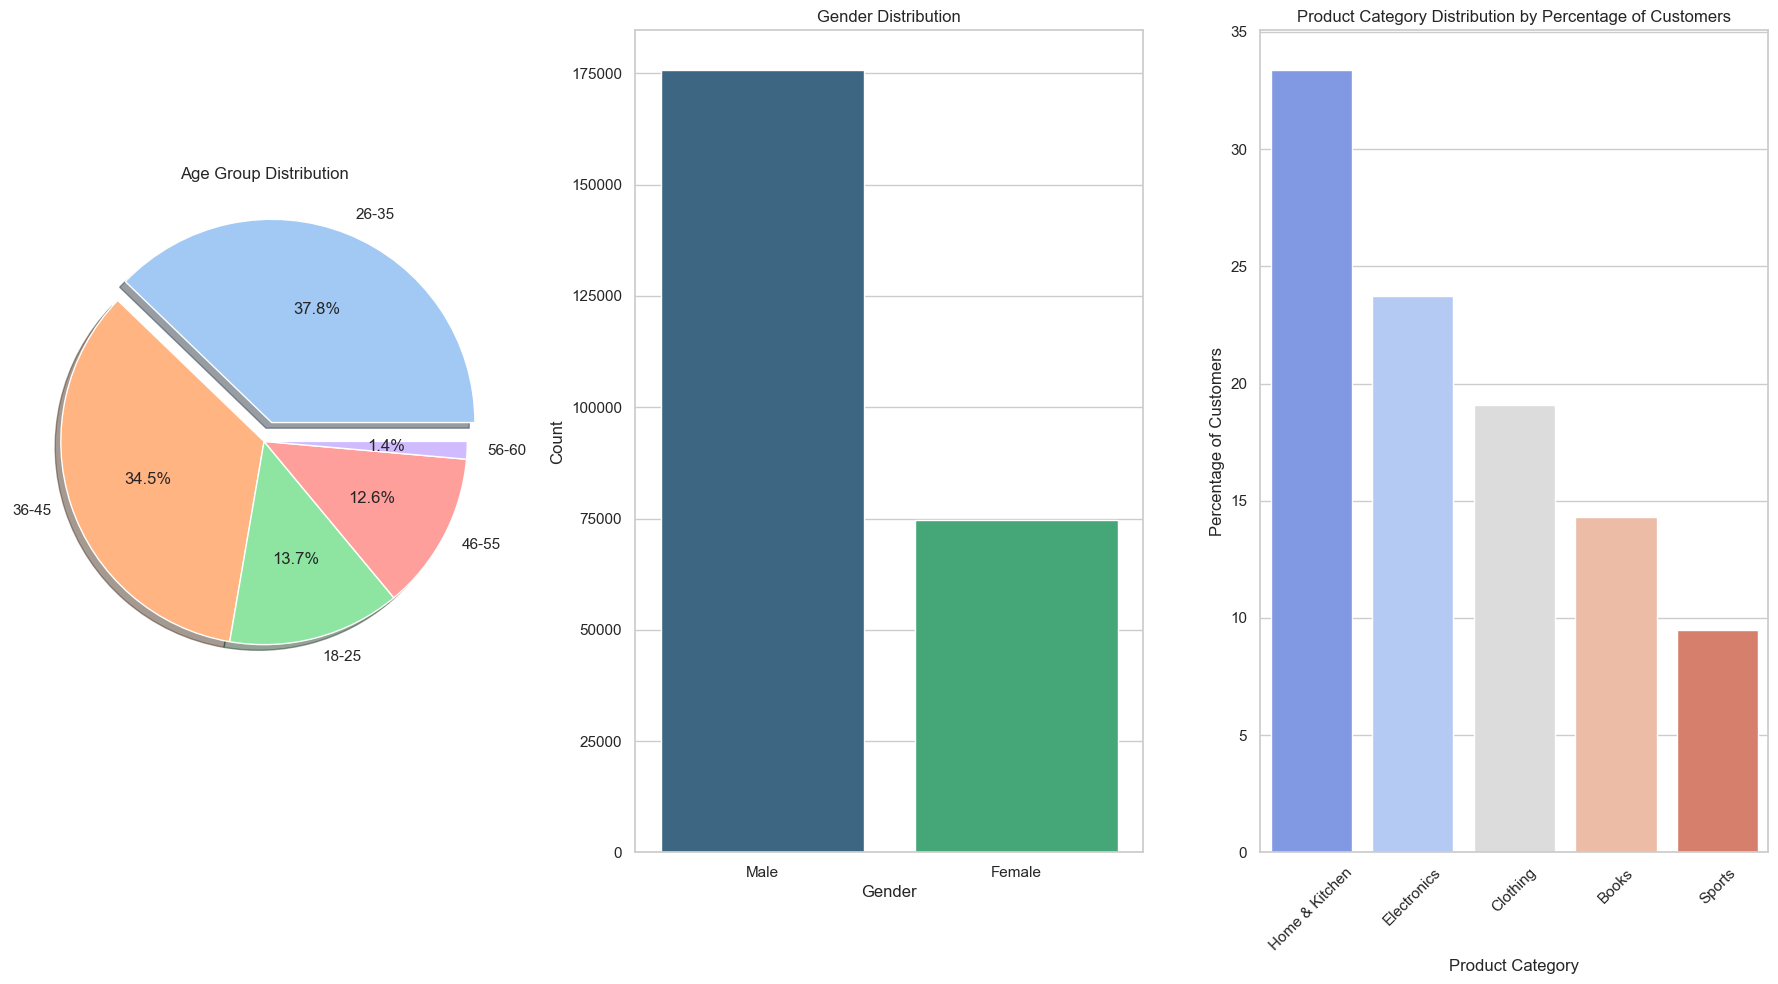

In [440]:
# Create subplots
fig, axes = plt.subplots(1,3, figsize=(18, 10))

# Pie Chart: Age Group Distribution
age_group_counts = df_e['Age_group'].value_counts()
axes[0].pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"),shadow=True, 
    explode=(0.1, 0, 0, 0,0))
axes[0].set_title("Age Group Distribution")

# Bar Chart: Gender Distribution
gender_counts = df_e['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="viridis", ax=axes[1])
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1].set_title("Gender Distribution")

# Bar Chart: Product Categories with Percentage of Customers
product_counts = df_e['Product_Category'].value_counts()
percentage = (product_counts / product_counts.sum()) * 100
sns.barplot(x=percentage.index, y=percentage.values, palette="coolwarm", ax=axes[2])
axes[2].set_xlabel("Product Category")
axes[2].set_ylabel("Percentage of Customers")
axes[2].set_title("Product Category Distribution by Percentage of Customers")
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()


## Purchase Analysis  

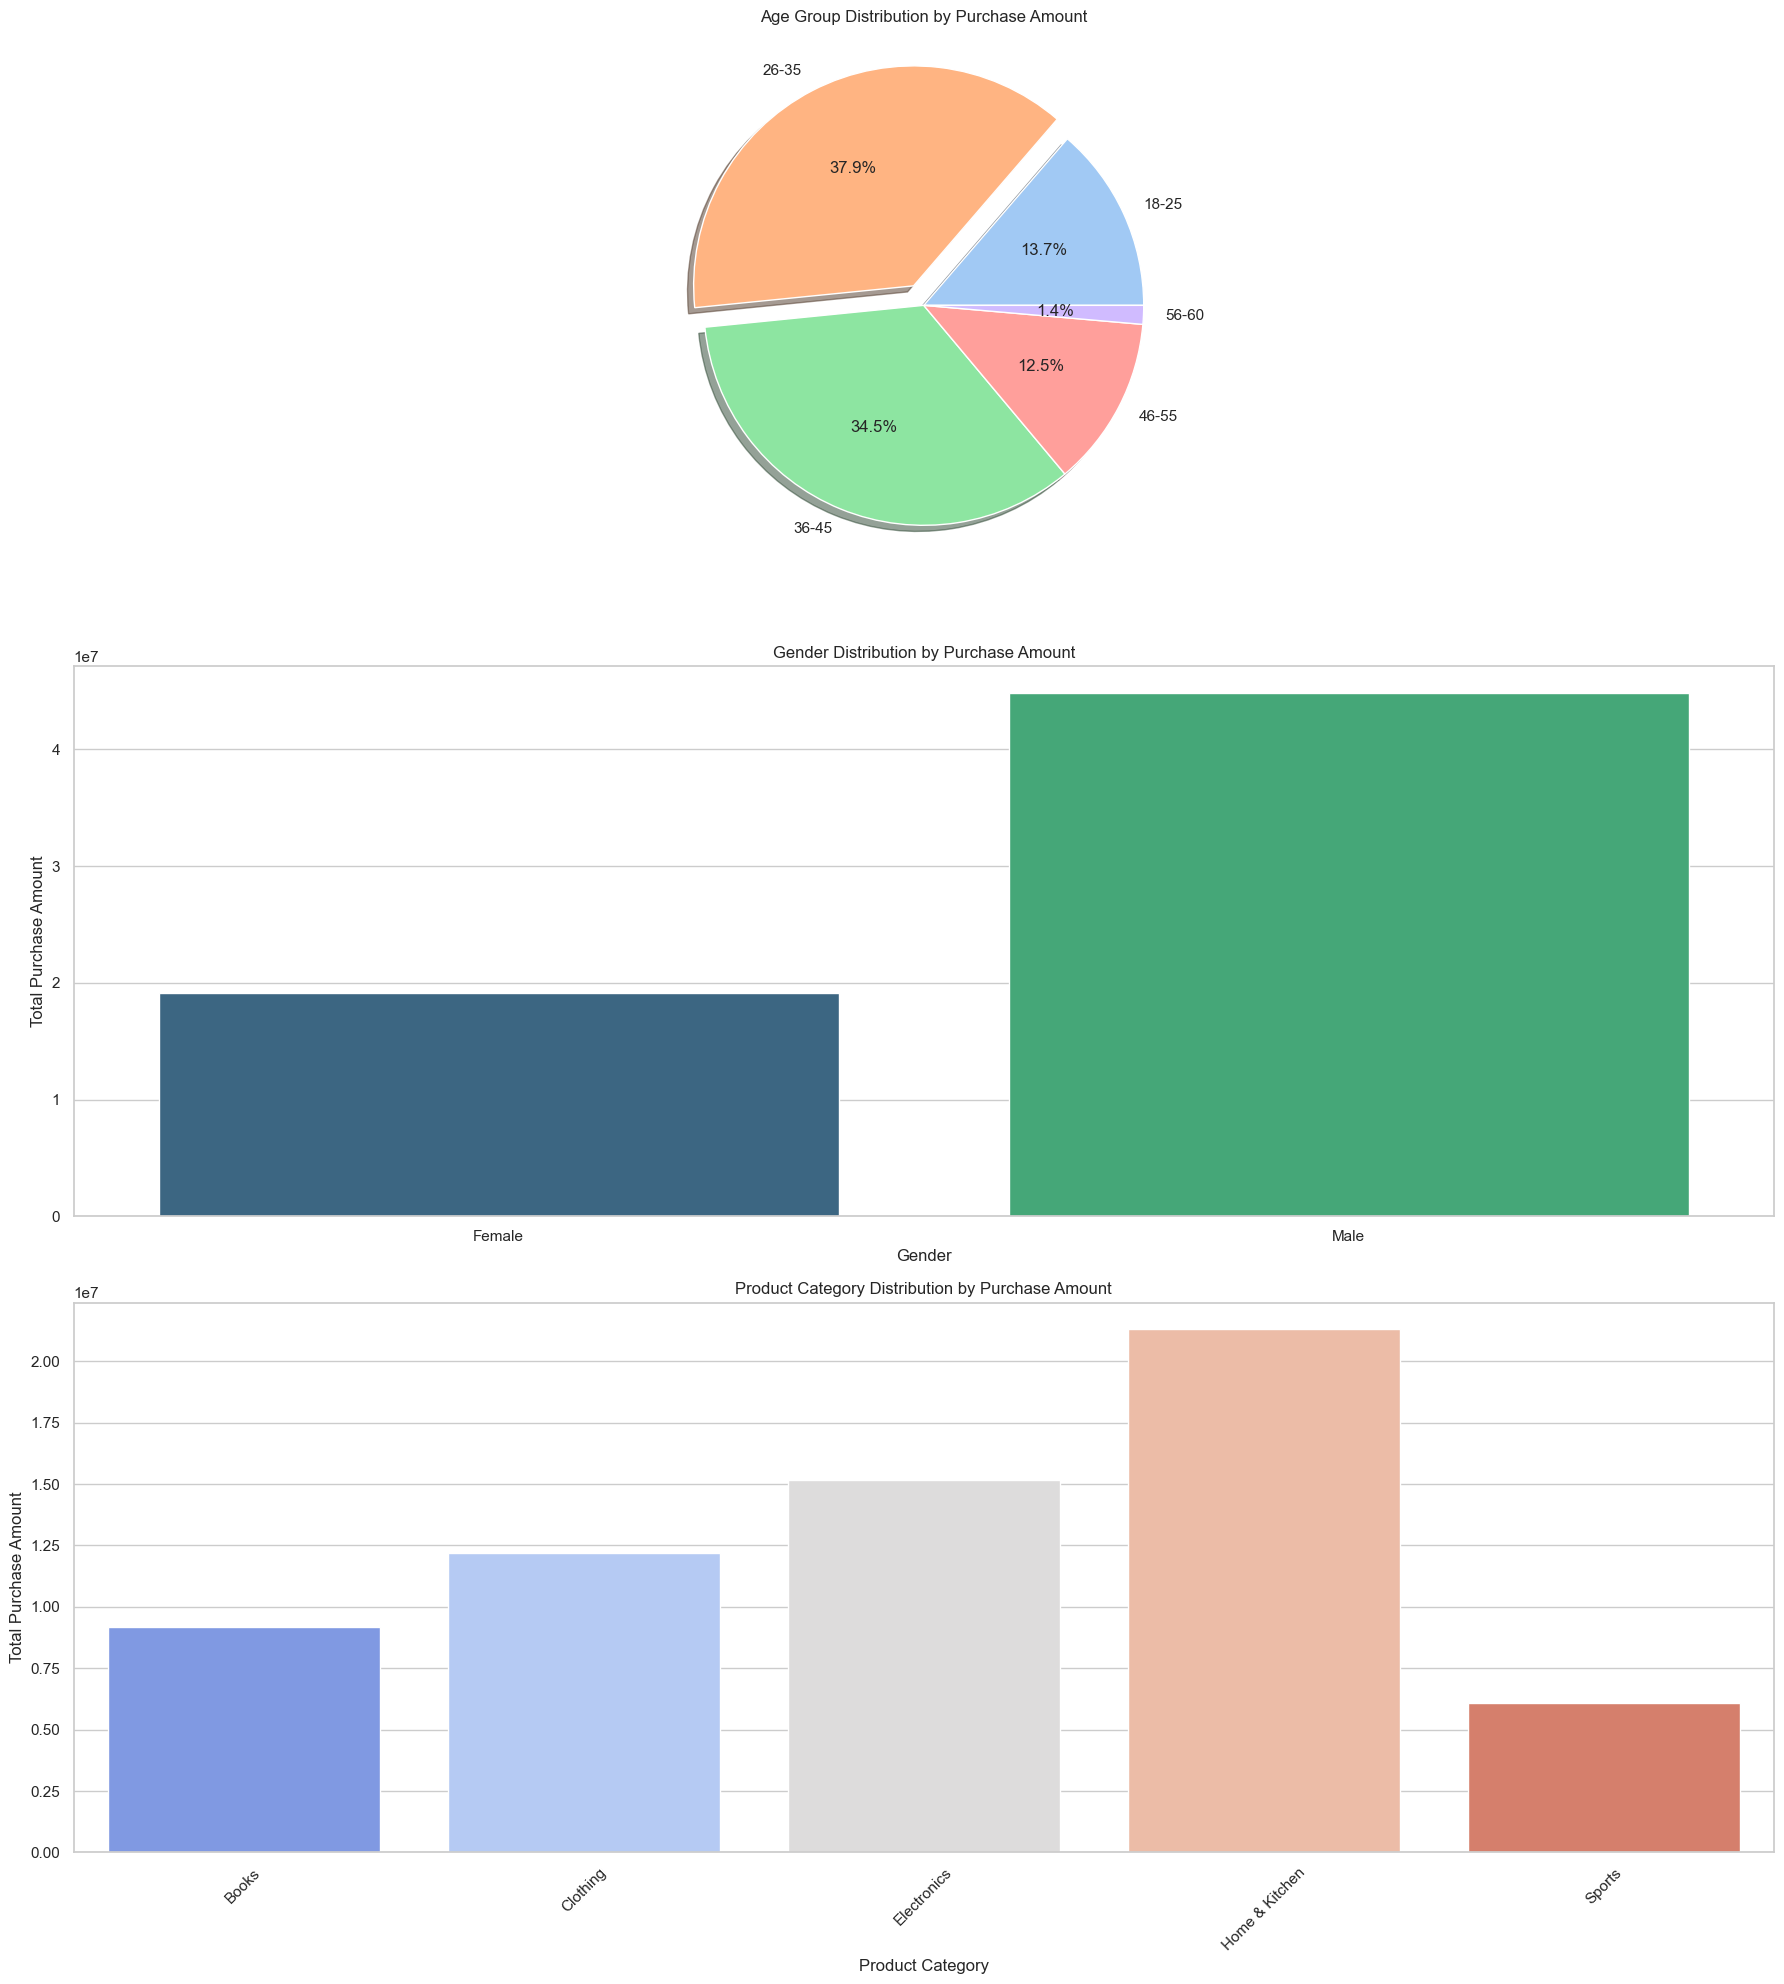

In [441]:
# Set plot style
sns.set(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(18, 20))

# Pie Chart: Age Group Distribution by Purchase Amount
age_group_purchase = df_e.groupby('Age_group')['Purchase_Amount'].sum()
axes[0].pie(age_group_purchase, labels=age_group_purchase.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"),shadow=True, 
    explode=(0, 0.1, 0, 0,0))
axes[0].set_title("Age Group Distribution by Purchase Amount")

# Bar Chart: Gender Distribution by Purchase Amount
gender_purchase = df_e.groupby('Gender')['Purchase_Amount'].sum()
sns.barplot(x=gender_purchase.index, y=gender_purchase.values, palette="viridis", ax=axes[1])
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Total Purchase Amount")
axes[1].set_title("Gender Distribution by Purchase Amount")

# Bar Chart: Product Categories with Purchase Amount
product_purchase = df_e.groupby('Product_Category')['Purchase_Amount'].sum()
sns.barplot(x=product_purchase.index, y=product_purchase.values, palette="coolwarm", ax=axes[2])
axes[2].set_xlabel("Product Category")
axes[2].set_ylabel("Total Purchase Amount")
axes[2].set_title("Product Category Distribution by Purchase Amount")
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

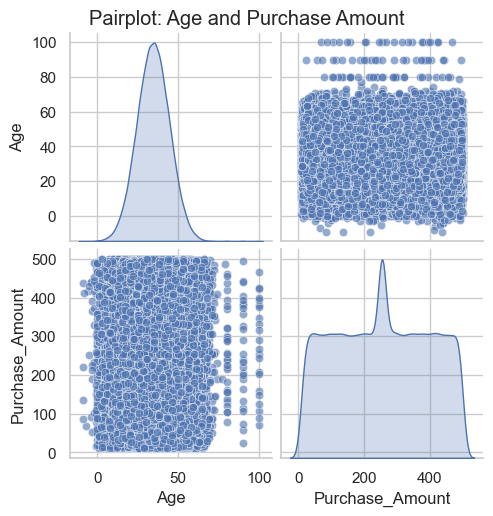

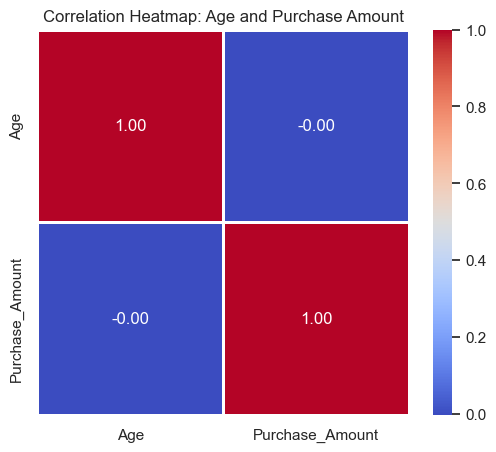

In [448]:
# Create a subset with continuous variables (Age, Purchase_Amount)
df_continuous = df_e[['Age', 'Purchase_Amount']]

# Pairplot: To show pairwise relationships between continuous variables
sns.pairplot(df_continuous, diag_kind='kde', height=2.5, plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot: Age and Purchase Amount', y=1.02)
plt.show()

# Correlation Matrix: Calculate correlation between continuous variables
correlation_matrix = df_continuous.corr()

# Heatmap: To visualize the correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, linecolor='white', cbar=True)
plt.title('Correlation Heatmap: Age and Purchase Amount')
plt.show()

## 1. T-Test (Comparing Average Purchase Amounts Between Genders)

##### Null Hypothesis (H₀): There is no significant difference in the average purchase amounts between genders.
##### Alternative Hypothesis (H₁): There is a significant difference in the average purchase amounts between genders.

In [442]:
## creating datafram for male and female 

df_male = df_e[df_e['Gender']== 'Male']['Purchase_Amount']
df_female = df_e[df_e['Gender']== 'Female']['Purchase_Amount']

In [443]:
df_male.sum()

44860154.45538417

In [444]:
df_female.sum()

19103076.834702063

In [445]:
df_male.dtypes
df_female.dtypes

dtype('float64')

In [461]:
## t-test
t_statistic, T_p_value = st.ttest_ind(df_male, df_female, equal_var=False)

print(f"T-Statistic: {t_statistic:.4f}")
print(f"T_P-Value: {t_p_value:.4f}")

T-Statistic: -0.9187
T_P-Value: 0.3583


In [462]:
alpha = 0.05
if T_p_value < alpha:
    print("Reject H0: Significant difference in purchase amounts between genders.")
else:
    print("Fail to reject H0: No significant difference in purchase amounts between genders.")

Fail to reject H0: No significant difference in purchase amounts between genders.


Since the P-Value (0.2314) is greater than the Alpha (0.05), we fail to reject the null hypothesis.

Interpretation: There is no significant difference in the average purchase amounts between males and females.

## 2. Chi-Square Test (Examining Relationship Between Product Categories & Age Groups)


##### Null Hypothesis (H₀): Product categories and age groups are independent.
##### Alternative Hypothesis (H₁): Product categories and age groups are not independent.

In [466]:
# Create a contingency table
contingency_table = pd.crosstab(df_e['Product_Category'],df_e['Age_group'])

chi2_stat, CHI_p_value, dof, expected = st.chi2_contingency(contingency_table)
print(f'chi2_stat:{chi2_stat}, CHI_p_value:{CHI_p_value}, dof:{dof}, expected:{expected}')

chi2_stat:14.48663055120902, CHI_p_value:0.5625093545151474, dof:16, expected:[[ 4637.86943017 12765.21214256 11652.64515185  4246.75834971
    472.51492572]
 [ 6176.09040298 16998.99175532 15517.42475187  5655.26129666
    629.23179317]
 [ 7676.00003395 21127.32372373 19285.9471203   7028.68369352
    782.04542851]
 [10797.34452002 29718.4721238  27128.32393589  9886.80550098
   1100.0539193 ]
 [ 3073.69561288  8460.0002546   7722.65904009  2814.49115914
    313.1539333 ]]


In [467]:
if CHI_p_value < alpha:
    print("Reject H0: There is a significant relationship between product category and age group.")
else:
    print("Fail to reject H0: No significant relationship between product category and age group.")

Fail to reject H0: No significant relationship between product category and age group.


Since the P-Value (0.5625) is greater than the Alpha (0.05), we fail to reject the null hypothesis.

Interpretation: There is no significant difference in the average purchase amounts between males and females.